2025.10.01.(수) [참고 티스토리](https://heytech.tistory.com/150)
# 랜덤포레스트

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings(action='ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')
print(train.head())

print("Train 데이터 개수:", len(train))
print("Test 데이터 개수:", len(test))

            ID   age gender  tenure  frequent  payment_interval  \
0  TRAIN_00000  54.0      F    47.0      22.0               8.0   
1  TRAIN_00001  30.0      M    16.0      15.0               5.0   
2  TRAIN_00002  29.0      M     8.0      30.0              21.0   
3  TRAIN_00003  38.0      F    38.0      23.0              10.0   
4  TRAIN_00004  25.0      F    52.0       3.0              17.0   

  subscription_type  contract_length  after_interaction  support_needs  
0            member               90               25.0              0  
1               vip              360               23.0              0  
2              plus               30               21.0              0  
3               vip               90                6.0              0  
4            member               30                1.0              2  
Train 데이터 개수: 30858
Test 데이터 개수: 13225


In [18]:
X = train.drop(columns=['ID', 'support_needs'])
Y = train['support_needs']
X_test = test.drop(columns=['ID'])
X.isnull().sum() # 확인 결과 결측치 없음

,0
age,0
gender,0
tenure,0
frequent,0
payment_interval,0
subscription_type,0
contract_length,0
after_interaction,0


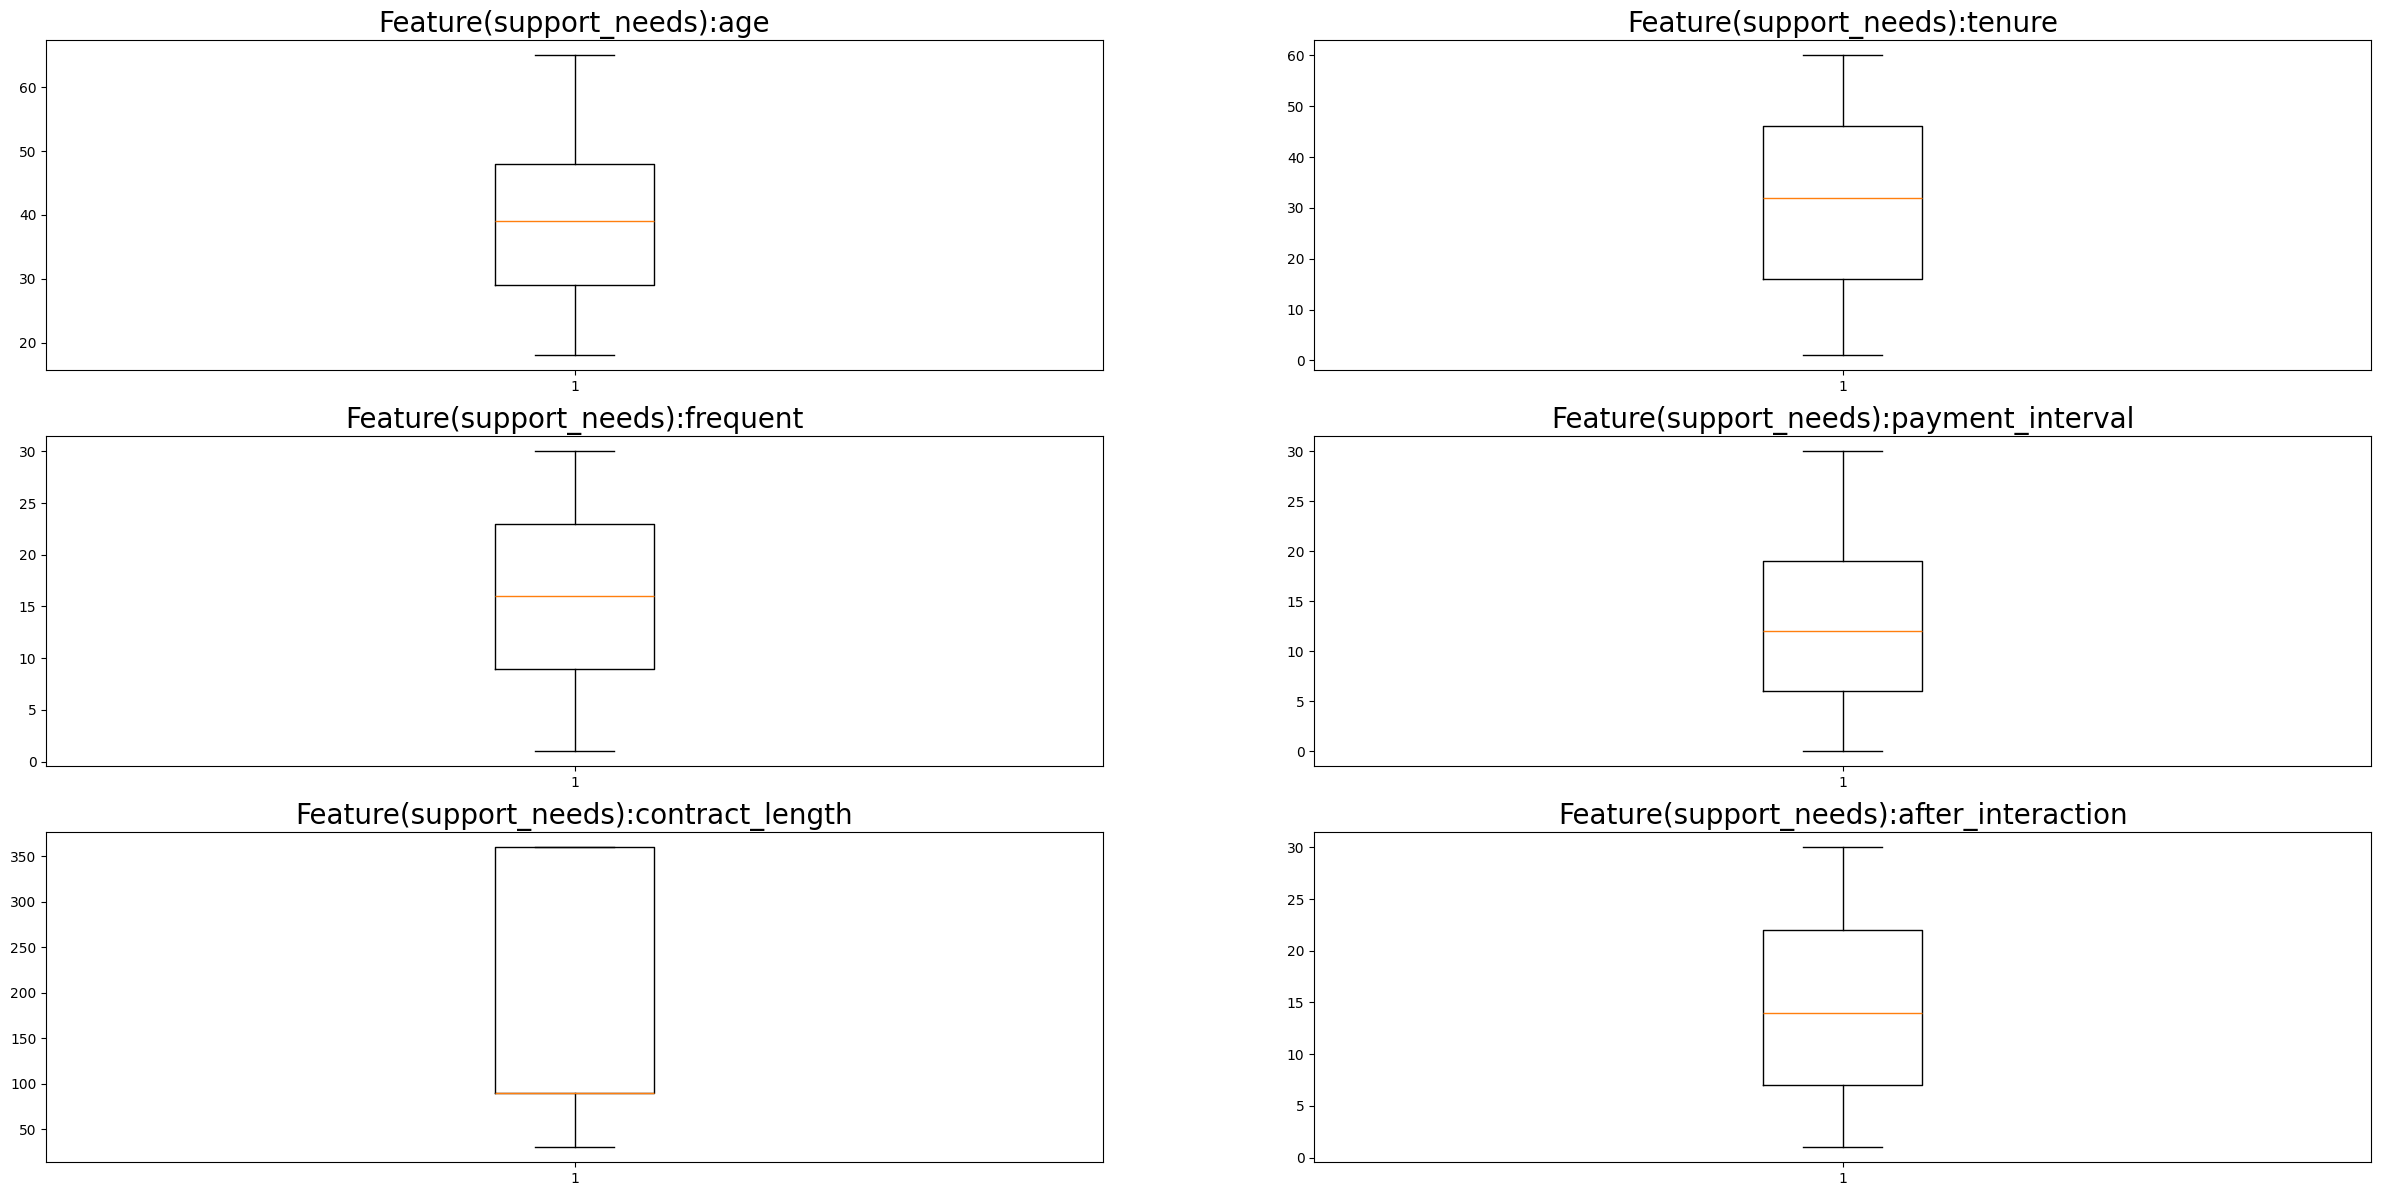

In [19]:
# 이상치 확인(Box Plot)

def boxplot_vis(data, target_name):
    plt.figure(figsize=(30, 30))
    for col_idx in range(len(data.columns)):
        plt.subplot(6, 2, col_idx+1)
        plt.boxplot(data[data.columns[col_idx]], flierprops = dict(markerfacecolor = 'r', marker = 'D'))
        plt.title("Feature" + "(" + target_name + "):" + data.columns[col_idx], fontsize = 20)
    plt.show()

boxplot_vis(X.select_dtypes(include='number'), "support_needs")

In [20]:
X_encoded = pd.get_dummies(X, columns=['gender', 'subscription_type'], drop_first=True) # 원핫인코딩(범주형 변수를 더미 변수화)

num_cols = X_encoded.select_dtypes(include='number').columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded[num_cols])
X_scaled = pd.DataFrame(X_scaled, columns=num_cols, index=X_encoded.index)

In [26]:
x_train, x_val, y_train, y_val = train_test_split(
    X_scaled, Y,
    test_size=0.2,        # 20%는 검증
    random_state=42,
    stratify=Y            # 클래스 비율 유지
)

In [31]:
rf = RFC(
    random_state=42,
    n_estimators=500,      # 과적합 방지 1: 증가시키기
    max_depth=20,          # 과2: 감
    min_samples_split=5,   # 과3: 증
    min_samples_leaf=2,    # 과4: 증
    max_features="sqrt",
    class_weight="balanced"
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, random_state=42)

Train Accuracy: 0.9503362229603824
Validation Accuracy: 0.495301360985094


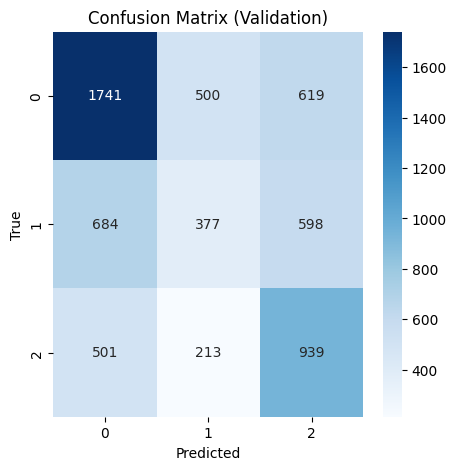

In [32]:
y_train_pred = rf.predict(x_train)
y_val_pred = rf.predict(x_val)


print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
# print("\nClassification Report (Validation):\n", classification_report(y_val, y_val_pred))


# 혼동 행렬
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap="Blues",
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()

- 이전에 한 일: 조기종료, 일부 변수만 쓴 학습 (실패)
- 다음에 할 일: 데이터 증강